In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


In [2]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import pandas as pd


def aplicar_suavizado_frecuencia(dsa_db, sigma_freq=0):
    """
    Aplica suavizado gaussiano entre frecuencias.

    dsa_db:
        DataFrame con filas = tiempo y columnas = frecuencia.

    sigma_freq:
        Intensidad del suavizado entre columnas de frecuencia.
        - 0: sin suavizado
        - 0.5: suavizado muy leve
        - 1: suavizado moderado
        - 1.5 o 2: suavizado más fuerte
    """

    if sigma_freq == 0:
        return dsa_db.copy()

    matriz_suav = gaussian_filter1d(
        dsa_db.to_numpy(dtype=float),
        sigma=sigma_freq,
        axis=1,
        mode="nearest"
    )

    return pd.DataFrame(
        matriz_suav,
        index=dsa_db.index,
        columns=dsa_db.columns
    )


def aplicar_suavizado_temporal(dsa_db, ventana_s=0):
    """
    Aplica suavizado temporal causal.

    ventana_s:
        - 0: sin suavizado temporal
        - 5, 10, 30, 60: media móvil de los últimos N segundos.
    """

    if ventana_s == 0:
        return dsa_db.copy()

    return dsa_db.rolling(
        window=ventana_s,
        min_periods=1,
        center=False
    ).mean()


def aplicar_shift_comparacion(dsa_recon, dsa_fa, shift_s):
    """
    Aplica shift para comparar dos matrices.

    Convención:
    - shift_s > 0:
        la reconstruida se compara contra la f_a desplazada hacia delante.
    - shift_s < 0:
        la reconstruida se compara contra la f_a desplazada hacia atrás.
    - shift_s = 0:
        comparación directa.

    Devuelve dos matrices con la misma longitud.
    """

    if shift_s < 0:
        A = dsa_recon.iloc[-shift_s:].reset_index(drop=True)
        B = dsa_fa.iloc[:len(A)].reset_index(drop=True)

    elif shift_s > 0:
        A = dsa_recon.iloc[:-shift_s].reset_index(drop=True)
        B = dsa_fa.iloc[shift_s:].reset_index(drop=True)

    else:
        A = dsa_recon.reset_index(drop=True)
        B = dsa_fa.reset_index(drop=True)

    n = min(len(A), len(B))
    A = A.iloc[:n]
    B = B.iloc[:n]

    return A, B


def evaluar_dsa_reconstruida(
    nombre,
    dsa_recon_db,
    dsa_fa_db,
    mask_comun,
    sigmas_freq=(0, 0.5, 1, 1.5, 2),
    ventanas_temporales=(0, 5, 10, 30, 60),
    shifts=range(-30, 31)
):
    """
    Evalúa una DSA reconstruida frente a la DSA original f_a.

    Para cada combinación de:
    - suavizado frecuencial
    - suavizado temporal
    - shift temporal

    calcula métricas globales sobre matrices normalizadas con z-score.
    """

    resultados = []

    for sigma_freq in sigmas_freq:

        # 1) Suavizado entre frecuencias
        dsa_freq = aplicar_suavizado_frecuencia(
            dsa_recon_db,
            sigma_freq=sigma_freq
        )

        for ventana in ventanas_temporales:

            # 2) Suavizado temporal
            dsa_temp = aplicar_suavizado_temporal(
                dsa_freq,
                ventana_s=ventana
            )

            # 3) Aplicar máscara común al final
            dsa_temp_mask = dsa_temp.copy()
            dsa_temp_mask.loc[mask_comun.values, :] = np.nan

            dsa_fa_mask = dsa_fa_db.copy()
            dsa_fa_mask.loc[mask_comun.values, :] = np.nan

            for shift in shifts:

                # 4) Aplicar shift para comparar
                A, B = aplicar_shift_comparacion(
                    dsa_recon=dsa_temp_mask,
                    dsa_fa=dsa_fa_mask,
                    shift_s=shift
                )

                # 5) Asegurar mismas columnas y longitud
                A, B = fun_dsa.preparar_matrices_para_comparacion(A, B)

                try:
                    # 6) Normalizar para comparar patrones
                    A_z = fun_dsa.zscore_global(A)
                    B_z = fun_dsa.zscore_global(B)

                    # 7) Métricas
                    met = fun_dsa.comparar_dsa_global(A_z, B_z)

                    resultados.append({
                        "metodo": nombre,
                        "sigma_freq": sigma_freq,
                        "suavizado_temporal_s": ventana,
                        "shift_s": shift,
                        "n_valores": met["n_valores_comparados"],
                        "Pearson": met["Pearson"],
                        "Spearman": met["Spearman"],
                        "MAE": met["MAE"],
                        "RMSE": met["RMSE"],
                        "bias": met["bias_B_menos_A"]
                    })

                except ValueError:
                    continue

    return pd.DataFrame(resultados)

# OG

#### Archivo f_a

In [3]:
ruta_base_advanced = "../data/data_bis_advanced"

archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


#### Archivo spa

In [4]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"


df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

## Unión de los 2

In [5]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_hor)

# las matrices que vienen de la f_a suelen mostrar valores entre el 49 y 94
matriz_hor, vmin_hor, vmax_hor, norm_hor, cmap_hor = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor, vmin=49, vmax=94, gamma=1)

In [6]:
cols_freq_fa = [c for c in dsa_plot_hor.columns]


print(np.nanmin(dsa_plot_hor[cols_freq_fa].values))
print(np.nanmax(dsa_plot_hor[cols_freq_fa].values))

print(np.nanpercentile(dsa_plot_hor[cols_freq_fa].values, 2))
print(np.nanpercentile(dsa_plot_hor[cols_freq_fa].values, 99.5))

55.61
103.02
70.0
96.87


# Procesado

In [7]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

In [8]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

### Reconstrucción desde EEG crudo

In [111]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

# se pierde un segundo por el uso de ventanas de 2 segundos con etiqueta temporal en el centro
""" 
La función no calcula una DSA para cada muestra aislada ni para cada segundo independiente. 
Calcula una DSA por ventanas completas de 2 segundos (usando 256 muestras).
La ventana avanza cada segundo (cada 128 muestras).

Resultado: Cada fila de la DSA final no sale de un único segundo, sino de una ventana de 2 segundos.


Por eso, con ventanas de 2 segundos y paso de 1 segundo, si tienes un registro de N segundos, se obtienen aproximadamente:
N - 1 filas espectrales. 
No se obtienen N filas, porque no se puede calcular una ventana completa de 2 segundos centrada 
en todos los segundos extremos sin salirse del registro.
"""

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_1_uV",
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_2_uV",
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media = df_dsa_canal1.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# array de los nombres de las columnas pasados a float
frecuencias_float = np.array([float(c) for c in cols_freq])

# calcular sef y mef solo para la dsa reconstruida del eeg 
# (basado en la potencia en uV)
# 1. Calculamos SEF y MEF (que tendrán 2119 o 2118 filas dependiendo de la ventana)
sef_eeg, mef_eeg = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media,
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

# 2. Averiguamos la longitud objetivo (las filas del DataFrame de tu archivo .spa o .f_a)
# Suponiendo que tienes cargado el dF original del spa/f_a en una variable (ej: df_spa)
longitud_objetivo = len(df_spa_unilat) 
longitud_actual = len(sef_eeg)
filas_faltantes = longitud_objetivo - longitud_actual

# 3. Rellenamos dinámicamente con NaNs
if filas_faltantes > 0:
    # Creamos un array con tantos NaNs como falten (normalmente 1)
    relleno_nan = np.full(filas_faltantes, np.nan)
    
    # Los añadimos al principio
    sef_pad = np.r_[relleno_nan, sef_eeg]
    mef_pad = np.r_[relleno_nan, mef_eeg]
else:
    # Si la ventana es de 1s, filas_faltantes es 0, se queda igual
    sef_pad = sef_eeg
    mef_pad = mef_eeg

# 4. Creamos las Series finales para plotear
sef_eeg_plot = pd.Series(sef_pad, name="SEF08")
mef_eeg_plot = pd.Series(mef_pad, name="MEDFRQ08")

# --- CONVERSIÓN A DECIBELIOS (Usando la ref documentada del BIS) ---
ref_potencia = 0.0001
df_dsa_media[cols_freq] = 10 * np.log10(
    (pot_media + 1e-12) / (ref_potencia**2)
)

In [112]:
print(np.nanmin(df_dsa_media[cols_freq].values))
print(np.nanmax(df_dsa_media[cols_freq].values))

print(np.nanpercentile(df_dsa_media[cols_freq].values, 2))
print(np.nanpercentile(df_dsa_media[cols_freq].values, 99.5))

42.06825408227754
129.82281516998063
72.35147912223097
114.70939350044868


In [113]:
cols_freq_fa = [c for c in dsa_plot_hor.columns]


print(np.nanmin(dsa_plot_hor[cols_freq_fa].values))
print(np.nanmax(dsa_plot_hor[cols_freq_fa].values))

print(np.nanpercentile(dsa_plot_hor[cols_freq_fa].values, 2))
print(np.nanpercentile(dsa_plot_hor[cols_freq_fa].values, 99.5))

55.61
103.02
70.0
96.87


### Adaptación temporal, máscara y plot de DSA EEG

In [114]:
df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_media,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

df_merge_plot["SEF08"] = sef_eeg_plot.values
df_merge_plot["MEDFRQ08"] = mef_eeg_plot.values

_, mask_total = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=15,
    umbral_ceros=0.9
)

mask_comun = mask_total.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color


In [115]:
# DSA original f_a con máscara común

""" 
Copia de la dsa proveniente del f_a para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun.values, :] = np.nan



# DSA reconstruida directa con máscara común

""" 
Copia de la dsa proveniente del eeg para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_eeg_directa_plot = dsa_eeg.copy()
dsa_eeg_directa_plot.loc[mask_comun.values, :] = np.nan

# Construcción para pruebas

In [116]:
def construir_dsa_db_desde_potencia(
    pot_matrix,
    df_template,
    cols_freq,
    frecuencias,
    hora_inicio,
    ref_uv_rms=0.0001,
    insertar_fila_inicial_nan=False
):
    """
    Convierte una matriz de potencia/densidad lineal a DSA en dB
    y la adapta al eje temporal absoluto.

    pot_matrix: matriz tiempo x frecuencia en escala lineal.
                son las opciones de potencia que se proponen

    df_template: DataFrame con columna tiempo_s y columnas de frecuencia, usado como plantilla 
                 de estructura.
                 Es el dataFrame justo tras la reconstrucción.

    cols_freq: columnas del dF generado después de la conversión por FFT -> las frecuencias
               columnas de frecuencia.

    frecuencias: array de frecuencias.

    hora_inicio: hora inicial absoluta del registro.

    ref_uv_rms: referencia usada para la conversión a dB.
    """

    df_tmp = df_template.copy()

    df_tmp[cols_freq] = 10 * np.log10(
        (pot_matrix + 1e-12) / (ref_uv_rms ** 2)
    )

    tiempo_tmp, dsa_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
        df_dsa=df_tmp,
        frecuencias=frecuencias,
        hora_inicio=hora_inicio,
        insertar_fila_inicial_nan=insertar_fila_inicial_nan
    )

    return tiempo_tmp, dsa_tmp

In [ ]:
pot_c1 = df_dsa_canal1[cols_freq].to_numpy(dtype=float)
pot_c2 = df_dsa_canal2[cols_freq].to_numpy(dtype=float)

opciones_canales = {
    "solo_canal_1": pot_c1,
    "solo_canal_2": pot_c2,
    "media_c1_c2": (pot_c1 + pot_c2) / 2,
    "maximo_c1_c2": np.maximum(pot_c1, pot_c2),
    "ponderada_70_30": 0.7 * pot_c1 + 0.3 * pot_c2,
    "ponderada_30_70": 0.3 * pot_c1 + 0.7 * pot_c2,
}

In [ ]:
todos_resultados_canales = []

dsa_canales_dict = {}

for nombre_opcion, pot_opcion in opciones_canales.items():

    print(f"Procesando: {nombre_opcion}")

    tiempo_tmp, dsa_tmp = construir_dsa_db_desde_potencia(
        pot_matrix=pot_opcion,
        df_template=df_dsa_canal1,
        cols_freq=cols_freq,
        frecuencias=frecuencias_c1,
        hora_inicio=hora_inicio,
        ref_uv_rms=0.0001,
        insertar_fila_inicial_nan=False
    )

    dsa_canales_dict[nombre_opcion] = dsa_tmp

    df_res = evaluar_dsa_reconstruida(
        nombre=nombre_opcion,
        dsa_recon_db=dsa_tmp,
        dsa_fa_db=dsa_unilat,
        mask_comun=mask_comun,
        sigmas_freq=[0, 0.5, 1, 1.5, 2, 2.5, 3],
        ventanas_temporales=[0, 5, 10, 30, 60],
        shifts=range(-30, 31)
    )

    todos_resultados_canales.append(df_res)

resultados_canales = pd.concat(
    todos_resultados_canales,
    ignore_index=True
)

resultados_canales.sort_values("Pearson", ascending=False).head(20)

In [ ]:
mejores_por_metodo = (
    resultados_canales
    .sort_values("Pearson", ascending=False)
    .groupby("metodo", as_index=False)
    .first()
    .sort_values("Pearson", ascending=False)
)

mejores_por_metodo

In [ ]:
mejor_global = resultados_canales.sort_values("Pearson", ascending=False).iloc[0]

mejor_global

In [ ]:
mejor_metodo = mejor_global["metodo"]
mejor_sigma_freq = mejor_global["sigma_freq"]
mejor_suavizado_temporal = int(mejor_global["suavizado_temporal_s"])
mejor_shift = int(mejor_global["shift_s"])

print("Mejor método:", mejor_metodo)
print("Sigma frecuencia:", mejor_sigma_freq)
print("Suavizado temporal:", mejor_suavizado_temporal)
print("Shift:", mejor_shift)
print("Pearson:", mejor_global["Pearson"])
print("Spearman:", mejor_global["Spearman"])
print("MAE:", mejor_global["MAE"])
print("RMSE:", mejor_global["RMSE"])

In [ ]:
# Recuperar la DSA base correspondiente al mejor método
dsa_mejor_base = dsa_canales_dict[mejor_metodo].copy()

# Suavizado en frecuencia
dsa_mejor_freq = aplicar_suavizado_frecuencia(
    dsa_mejor_base,
    sigma_freq=mejor_sigma_freq
)

# Suavizado temporal
dsa_mejor_temp = aplicar_suavizado_temporal(
    dsa_mejor_freq,
    ventana_s=mejor_suavizado_temporal
)

# Mantener duración completa y aplicar shift con NaN
dsa_mejor_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_mejor_temp.index,
    columns=dsa_mejor_temp.columns
)

dsa_mejor_shift_full.iloc[mejor_shift:, :] = (
    dsa_mejor_temp.iloc[:-mejor_shift, :].to_numpy()
)

# Aplicar máscara común al final
dsa_mejor_shift_full.loc[mask_comun.values, :] = np.nan

# Preparar escala de color
matriz_mejor, vmin_mejor, vmax_mejor, norm_mejor, cmap_mejor = fun_dsa.preparar_escala_color_dsa(
    dsa_mejor_shift_full,
    gamma=0.3
)

In [ ]:
fig_mejor, ax_mejor, ax_band_mejor, cax_mejor = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg,
    frecuencias=frecuencias_c1,
    matriz=matriz_mejor,
    norm=norm_mejor,
    cmap=cmap_mejor,
    df_merge=None,
    titulo=f"Mejor DSA reconstruida: {mejor_metodo}, sigma={mejor_sigma_freq}, suav={mejor_suavizado_temporal}s, shift={mejor_shift}s",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun,
    mostrar_sef=True,
    mostrar_mef=True
)

### Comprobar que ambas matrices están alineadas

In [117]:
print("DSA f_a:", dsa_fa_plot.shape)
print("DSA EEG:", dsa_eeg_directa_plot.shape)

print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

print("Rango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_directa_plot.values), np.nanmax(dsa_eeg_directa_plot.values))

print("Rango DSA f_a:")
print(np.nanmin(dsa_fa_plot.values), np.nanmax(dsa_fa_plot.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
¿Tiempos iguales?
True
Rango DSA EEG reconstruida:
45.91220504499371 129.82281516998063
Rango DSA f_a:
55.61 103.02


## Preparar escalas de color de f_a y EEG directa

In [118]:
matriz_fa, vmin_fa, vmax_fa, norm_fa, cmap_fa = fun_dsa.preparar_escala_color_dsa(
    dsa_fa_plot,
    vmin=49,
    vmax=94,
    gamma=1
)

matriz_eeg, vmin_eeg, vmax_eeg, norm_eeg, cmap_eeg = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_directa_plot,
    gamma=0.4
)

### Comparación base

In [119]:
dsa_eeg_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_directa_plot,
    dsa_fa_plot
)

dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_comparacion)
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_comparacion)

metricas_base = fun_dsa.comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_base

{'n_valores_comparados': 118380,
 'MAE': np.float64(0.8753365527246261),
 'RMSE': np.float64(1.1239939748747863),
 'bias_B_menos_A': np.float64(1.3665853191236663e-15),
 'Pearson': np.float64(0.3683187722225891),
 'Spearman': np.float64(0.29411979746867667)}

### Correlación por frecuencia

In [120]:
df_corr_freq = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_z,
    dsa_fa_z
)

"""plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq["frecuencia_Hz"],
    df_corr_freq["correlacion"],
    marker="o"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()"""

'plt.figure(figsize=(12, 4))\n\nplt.plot(\n    df_corr_freq["frecuencia_Hz"],\n    df_corr_freq["correlacion"],\n    marker="o"\n)\n\nfor f in [4, 8, 13]:\n    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)\n\nplt.axhline(0, color="gray", linestyle="--", linewidth=1)\n\nplt.xlabel("Frecuencia (Hz)")\nplt.ylabel("Correlación")\nplt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")\nplt.tight_layout()\nplt.show()'

### Suavizado temporal

Suavizado temporal de la DSA reconstruida desde EEG

La DSA reconstruida desde el EEG crudo viene de un cálculo directo y produce una DSA con muchos cambios rápidos. 

La DSA del f_a del BIS se ve más suave y no cambia tan bruscamente de segundo a segundo. Sugiere que el BIS podría aplicar algún tipo de promedio temporal interno antes de guardar el f_a.

### Suavizado en frecuencia

In [121]:
sigmas_freq = [0, 0.5, 1, 1.5, 2]
ventanas_temporales = [1, 5, 10, 30, 60]
shifts = range(0, 31)

resultados_freq = evaluar_dsa_reconstruida(
    nombre="EEG media canales + suavizado frecuencia",
    dsa_recon_db=dsa_eeg,
    dsa_fa_db=dsa_unilat,
    mask_comun=mask_comun,
    sigmas_freq=sigmas_freq,
    ventanas_temporales=ventanas_temporales,
    shifts=shifts
)

resultados_freq.sort_values("Pearson", ascending=False).head(15)

,metodo,sigma_freq,suavizado_temporal_s,shift_s,n_valores,Pearson,Spearman,MAE,RMSE,bias
723,EEG media canales + suavizado frecuencia,2.0,30,10,114540,0.761759,0.732933,0.524809,0.689480,-0.002156
724,EEG media canales + suavizado frecuencia,2.0,30,11,114360,0.761654,0.732731,0.525486,0.689769,-0.003022
722,EEG media canales + suavizado frecuencia,2.0,30,9,114780,0.761019,0.731998,0.525245,0.690459,-0.001081
725,EEG media canales + suavizado frecuencia,2.0,30,12,114180,0.760696,0.731348,0.527191,0.691250,-0.003756
568,EEG media canales + suavizado frecuencia,1.5,30,10,114540,0.760179,0.733430,0.526215,0.691800,-0.002173
569,EEG media canales + suavizado frecuencia,1.5,30,11,114360,0.760056,0.733215,0.526866,0.692116,-0.003032
567,EEG media canales + suavizado frecuencia,1.5,30,9,114780,0.759457,0.732496,0.526652,0.692744,-0.001101
721,EEG media canales + suavizado frecuencia,2.0,30,8,115080,0.759401,0.729920,0.526887,0.692832,-0.000469
570,EEG media canales + suavizado frecuencia,1.5,30,12,114180,0.759086,0.731810,0.528540,0.693613,-0.003762
726,EEG media canales + suavizado frecuencia,2.0,30,13,113940,0.758808,0.728586,0.529992,0.693949,-0.004687


In [122]:
resultados_freq.sort_values("Spearman", ascending=False).head(15)

,metodo,sigma_freq,suavizado_temporal_s,shift_s,n_valores,Pearson,Spearman,MAE,RMSE,bias
413,EEG media canales + suavizado frecuencia,1.0,30,10,114540,0.758586,0.733609,0.527683,0.694125,-0.002189
568,EEG media canales + suavizado frecuencia,1.5,30,10,114540,0.760179,0.733430,0.526215,0.691800,-0.002173
414,EEG media canales + suavizado frecuencia,1.0,30,11,114360,0.758443,0.733369,0.528320,0.694474,-0.003042
258,EEG media canales + suavizado frecuencia,0.5,30,10,114540,0.757410,0.733252,0.529049,0.695835,-0.002200
569,EEG media canales + suavizado frecuencia,1.5,30,11,114360,0.760056,0.733215,0.526866,0.692116,-0.003032
259,EEG media canales + suavizado frecuencia,0.5,30,11,114360,0.757243,0.732974,0.529693,0.696219,-0.003048
723,EEG media canales + suavizado frecuencia,2.0,30,10,114540,0.761759,0.732933,0.524809,0.689480,-0.002156
103,EEG media canales + suavizado frecuencia,0.0,30,10,114540,0.756979,0.732848,0.529601,0.696458,-0.002202
724,EEG media canales + suavizado frecuencia,2.0,30,11,114360,0.761654,0.732731,0.525486,0.689769,-0.003022
412,EEG media canales + suavizado frecuencia,1.0,30,9,114780,0.757885,0.732686,0.528112,0.695033,-0.001120


### Suavizado + shift

In [123]:
ventanas_sp_smooth = [5, 10, 30, 60]

df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comparacion,
    dsa_fa_comparacion,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=range(0, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
133,30,11,0.756067,0.729172,0.530894,0.697365
134,30,12,0.755670,0.728223,0.531748,0.697929
132,30,10,0.755553,0.728827,0.531156,0.698101
135,30,13,0.754286,0.725853,0.533840,0.699892
131,30,9,0.754103,0.727141,0.532456,0.700154
136,30,14,0.751863,0.722055,0.537064,0.703296
130,30,8,0.751744,0.724153,0.534811,0.703519


In [124]:
df_suav_shift.sort_values("Spearman", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
133,30,11,0.756067,0.729172,0.530894,0.697365
132,30,10,0.755553,0.728827,0.531156,0.698101
134,30,12,0.755670,0.728223,0.531748,0.697929
131,30,9,0.754103,0.727141,0.532456,0.700154
135,30,13,0.754286,0.725853,0.533840,0.699892
130,30,8,0.751744,0.724153,0.534811,0.703519
136,30,14,0.751863,0.722055,0.537064,0.703296


### Tabla resumen final

La variante que mejor aproximó la DSA reconstruida desde EEG crudo a la DSA del archivo `f_a` fue la media de potencias de los dos canales, calculada a partir de densidad espectral de potencia y convertida posteriormente a dB. 

Tras aplicar un suavizado temporal causal de 30 s y un desplazamiento temporal de 10 u 11 s, se obtuvo una correlación de Pearson de aproximadamente 0.706 y una correlación de Spearman de aproximadamente 0.704. 

Esto sugiere que el archivo `f_a` incorpora información espectral de ambos canales, así como procesamiento temporal suavizado y un posible retardo asociado al cálculo interno del monitor BIS.

In [125]:
mejor_pearson = df_suav_shift.sort_values("Pearson", ascending=False).iloc[0]
mejor_spearman = df_suav_shift.sort_values("Spearman", ascending=False).iloc[0]

df_resumen_final = pd.DataFrame([
    {
        "criterio": "Mejor Pearson",
        "suavizado_s": mejor_pearson["suavizado_s"],
        "shift_s": mejor_pearson["shift_s"],
        "Pearson": mejor_pearson["Pearson"],
        "Spearman": mejor_pearson["Spearman"],
        "MAE": mejor_pearson["MAE"],
        "RMSE": mejor_pearson["RMSE"],
    },
    {
        "criterio": "Mejor Spearman",
        "suavizado_s": mejor_spearman["suavizado_s"],
        "shift_s": mejor_spearman["shift_s"],
        "Pearson": mejor_spearman["Pearson"],
        "Spearman": mejor_spearman["Spearman"],
        "MAE": mejor_spearman["MAE"],
        "RMSE": mejor_spearman["RMSE"],
    }
])

df_resumen_final

,criterio,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
0,Mejor Pearson,30.0,11.0,0.756067,0.729172,0.530894,0.697365
1,Mejor Spearman,30.0,11.0,0.756067,0.729172,0.530894,0.697365


## Suavizado limpio

In [126]:
suavizado_final = 30

dsa_eeg_suav = dsa_eeg.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

In [127]:


# máscara común al final
dsa_eeg_suav_plot = dsa_eeg_suav.copy()
dsa_eeg_suav_plot.loc[mask_comun.values, :] = np.nan

matriz_opt, vmin_opt, vmax_opt, norm_opt, cmap_opt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_plot,
    gamma=0.25
)

## Comprobación de bandas blancas

In [128]:
mask_blanca_directa = dsa_eeg_directa_plot.isna().all(axis=1)
mask_blanca_suav = dsa_eeg_suav_plot.isna().all(axis=1)

print("bandas blancas directa vs suavizada")
print((mask_blanca_directa == mask_blanca_suav).all())

print("Diferencias:")
print((mask_blanca_directa != mask_blanca_suav).sum())

bandas blancas directa vs suavizada
True
Diferencias:
0


## Al haber recortado 10 segundos


In [129]:
shift_final = 11

# matriz vacía del mismo tamaño que la DSA suavizada original
dsa_eeg_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_suav.index,
    columns=dsa_eeg_suav.columns
)

# Desplazar la DSA suavizada hacia delante:
# las filas originales 0:-shift pasan a ocupar las filas shift:
dsa_eeg_suav_shift_full.iloc[shift_final:, :] = dsa_eeg_suav.iloc[:-shift_final, :].to_numpy()

# Aplicar la máscara común sobre la línea temporal original completa
dsa_eeg_suav_shift_full.loc[mask_comun.values, :] = np.nan

# Preparar escala de color
matriz_opt_desfase_full, vmin_opt_desfase_full, vmax_opt_desfase_full, norm_opt_desfase_full, cmap_opt_desfase_full = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_full,
    gamma=0.25
)

print("Tiempo:", len(tiempo_fa_unilat))
print("f_a:", matriz_hor.shape)
print("shift full:", matriz_opt_desfase_full.shape)

Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


## Comprobación forma DSA

In [130]:
print("DSA f_a:", dsa_fa_plot.shape)
print("DSA EEG:", dsa_eeg_directa_plot.shape)
print("DSA suavizada:", dsa_eeg_suav_plot.shape)
print("DSA shift:", dsa_eeg_suav_shift_full.shape)

print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())


print("Rango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_directa_plot.values), np.nanmax(dsa_eeg_directa_plot.values))

print("Rango DSA f_a:")
print(np.nanmin(dsa_fa_plot.values), np.nanmax(dsa_fa_plot.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
DSA suavizada: (2119, 60)
DSA shift: (2119, 60)
¿Tiempos iguales?
True
Rango DSA EEG reconstruida:
45.91220504499371 129.82281516998063
Rango DSA f_a:
55.61 103.02


# COMPARACIÓN FINAL

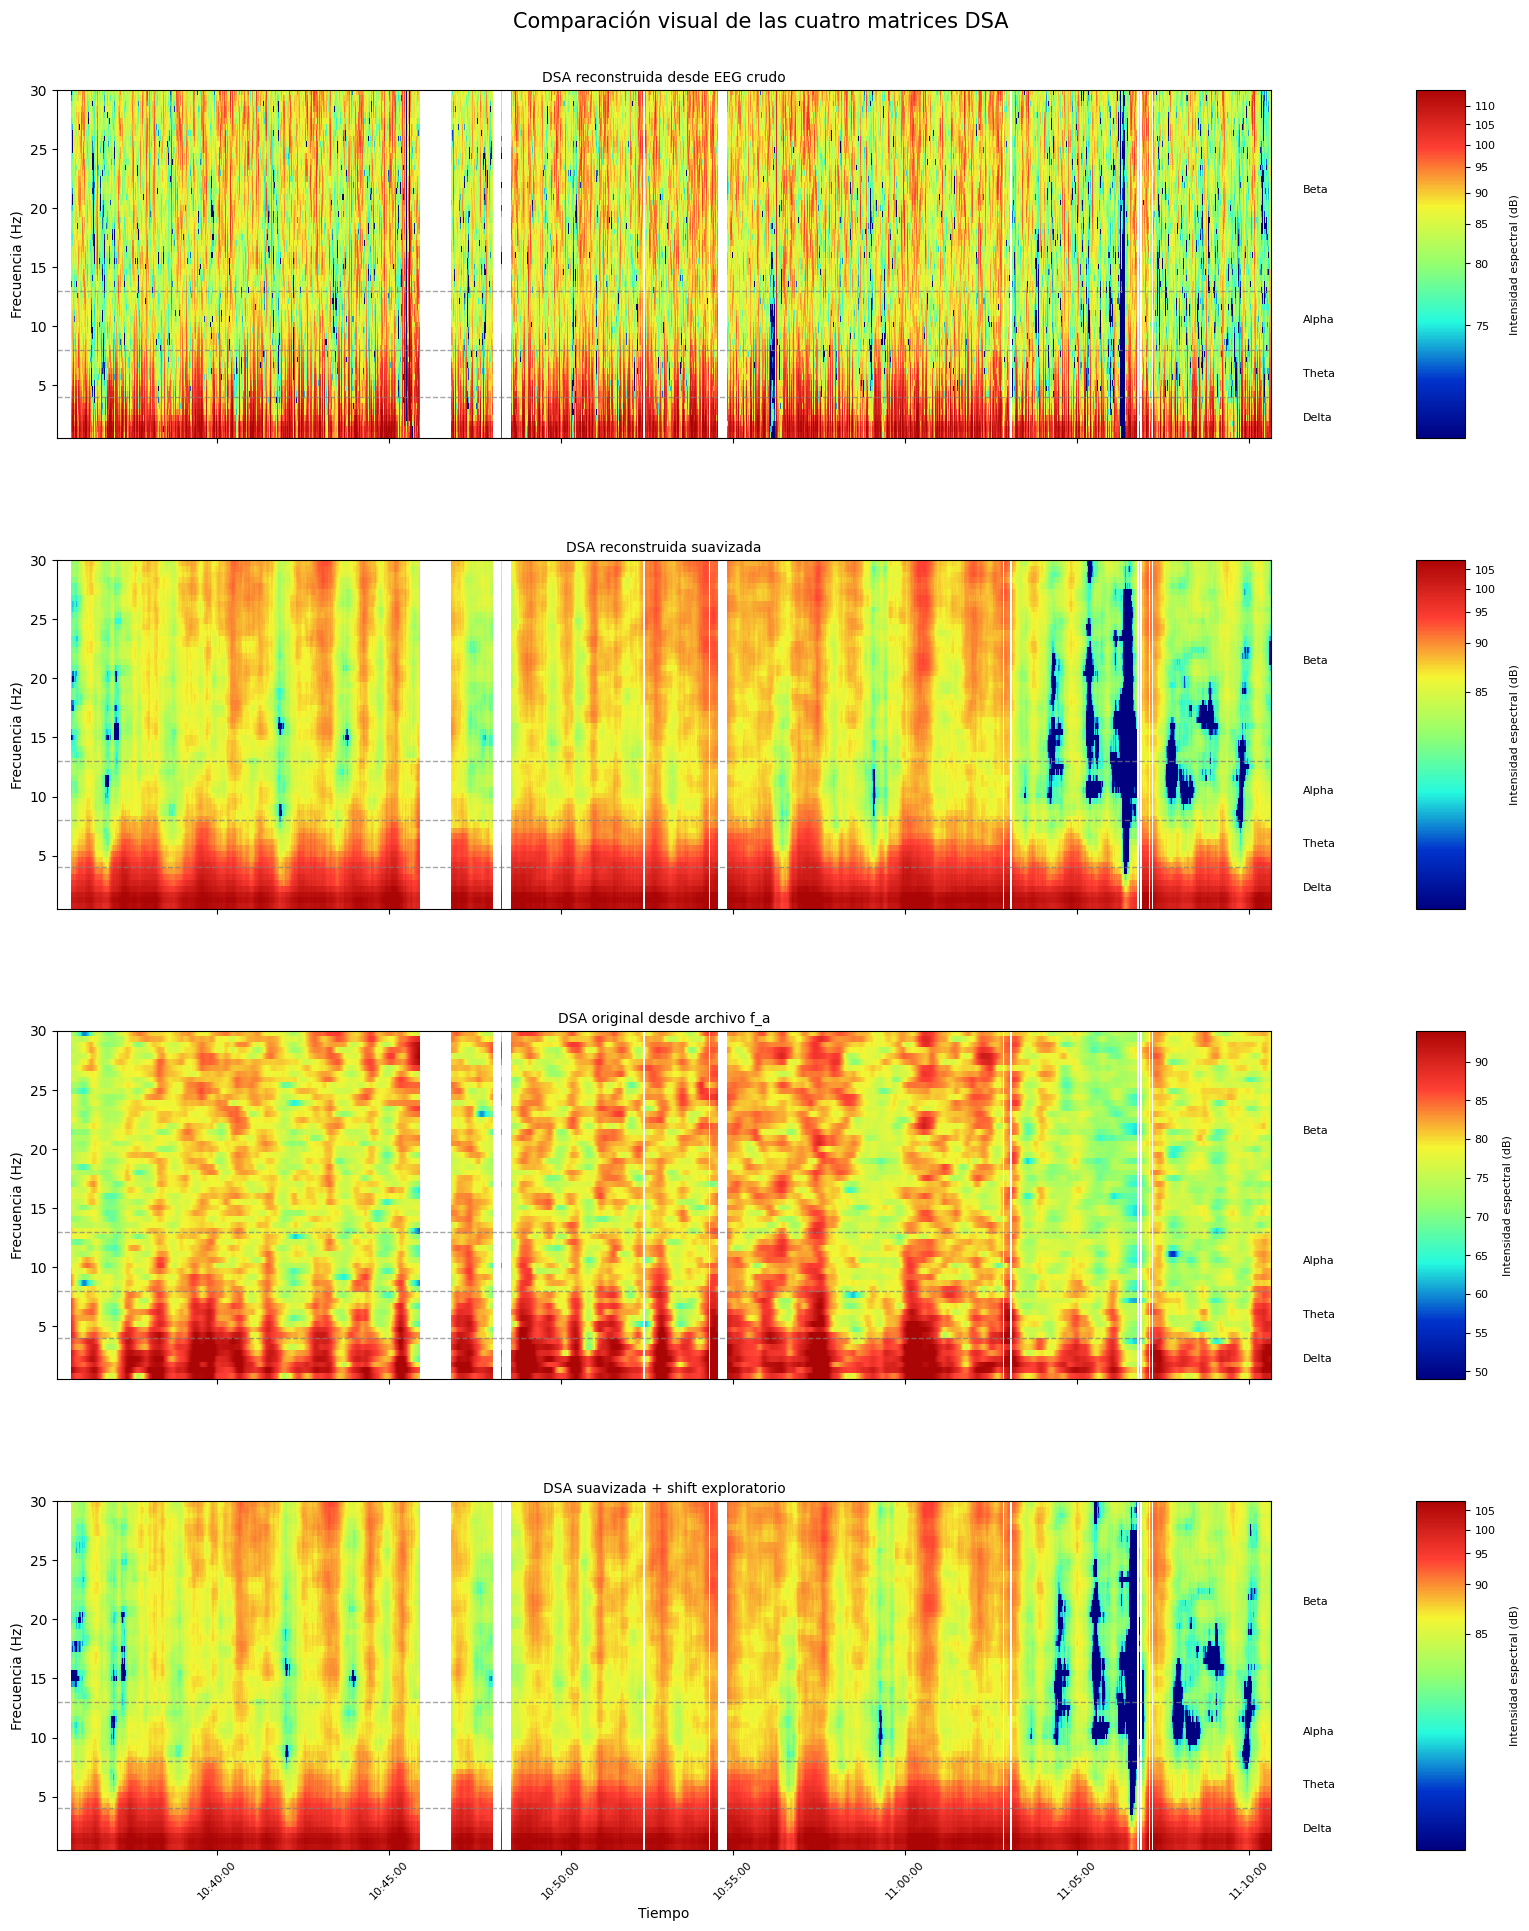

In [131]:
paneles = [
    
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_eeg,
        "norm": norm_eeg,
        "cmap": cmap_eeg,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida desde EEG crudo",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt,
        "norm": norm_opt,
        "cmap": cmap_opt,
        "df_merge": df_merge_plot,
        "titulo": "DSA reconstruida suavizada",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_fa_unilat,
        "frecuencias": dsa_fa_plot.columns.astype(float),
        "matriz": matriz_fa,
        "norm": norm_fa,
        "cmap": cmap_fa,
        "df_merge": df_merge_hor,
        "titulo": "DSA original desde archivo f_a",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_desfase_full,
        "norm": norm_opt_desfase_full,
        "cmap": cmap_opt_desfase_full,
        "df_merge": df_merge_plot,
        "titulo": "DSA suavizada + shift exploratorio",
        "etiqueta_colorbar": "Intensidad espectral (dB)",
        "mask_total": mask_comun
    }
]

fig_grid, axes_grid = fun_dsa.plot_cuadricula_4_dsa(
    paneles,
    titulo_general="Comparación visual de las cuatro matrices DSA"
)

# Cálculo de SEF / MEF propios

In [132]:
# ============================================================
# SEF / MEF propios para cada representación
# ============================================================

suavizado_final=30

# 1. SEF/MEF de referencia del BIS, extraídos del .spa
sef_fa_spa = df_merge_hor["SEF08"].copy()
mef_fa_spa = df_merge_hor["MEDFRQ08"].copy()


# 2. SEF/MEF de la DSA reconstruida directa desde EEG
frecuencias_float = np.array([float(c) for c in cols_freq])

sef_eeg, mef_eeg = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media,
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

sef_eeg_plot = pd.Series(np.r_[sef_eeg], name="SEF08")
mef_eeg_plot = pd.Series(np.r_[mef_eeg], name="MEDFRQ08")

df_merge_eeg = df_merge_plot.copy()
df_merge_eeg["SEF08"] = sef_eeg_plot.values
df_merge_eeg["MEDFRQ08"] = mef_eeg_plot.values


# 3. SEF/MEF de la DSA reconstruida suavizada
df_pot_media = pd.DataFrame(pot_media, columns=cols_freq)

df_pot_media_suav = df_pot_media.rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

sef_eeg_suav, mef_eeg_suav = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=df_pot_media_suav.to_numpy(dtype=float),
    frecuencias=frecuencias_float,
    percentil_sef=0.95,
    percentil_mef=0.50
)

sef_eeg_suav_plot = pd.Series(np.r_[sef_eeg_suav], name="SEF08")
mef_eeg_suav_plot = pd.Series(np.r_[mef_eeg_suav], name="MEDFRQ08")

df_merge_suav = df_merge_plot.copy()
df_merge_suav["SEF08"] = sef_eeg_suav_plot.values
df_merge_suav["MEDFRQ08"] = mef_eeg_suav_plot.values


# 4. SEF/MEF de la DSA suavizada + shift, manteniendo duración original
df_merge_suav_shift_full = df_merge_suav.copy()

df_merge_suav_shift_full["SEF08"] = np.nan
df_merge_suav_shift_full["MEDFRQ08"] = np.nan

df_merge_suav_shift_full.loc[shift_final:, "SEF08"] = sef_eeg_suav_plot.iloc[:-shift_final].to_numpy()
df_merge_suav_shift_full.loc[shift_final:, "MEDFRQ08"] = mef_eeg_suav_plot.iloc[:-shift_final].to_numpy()

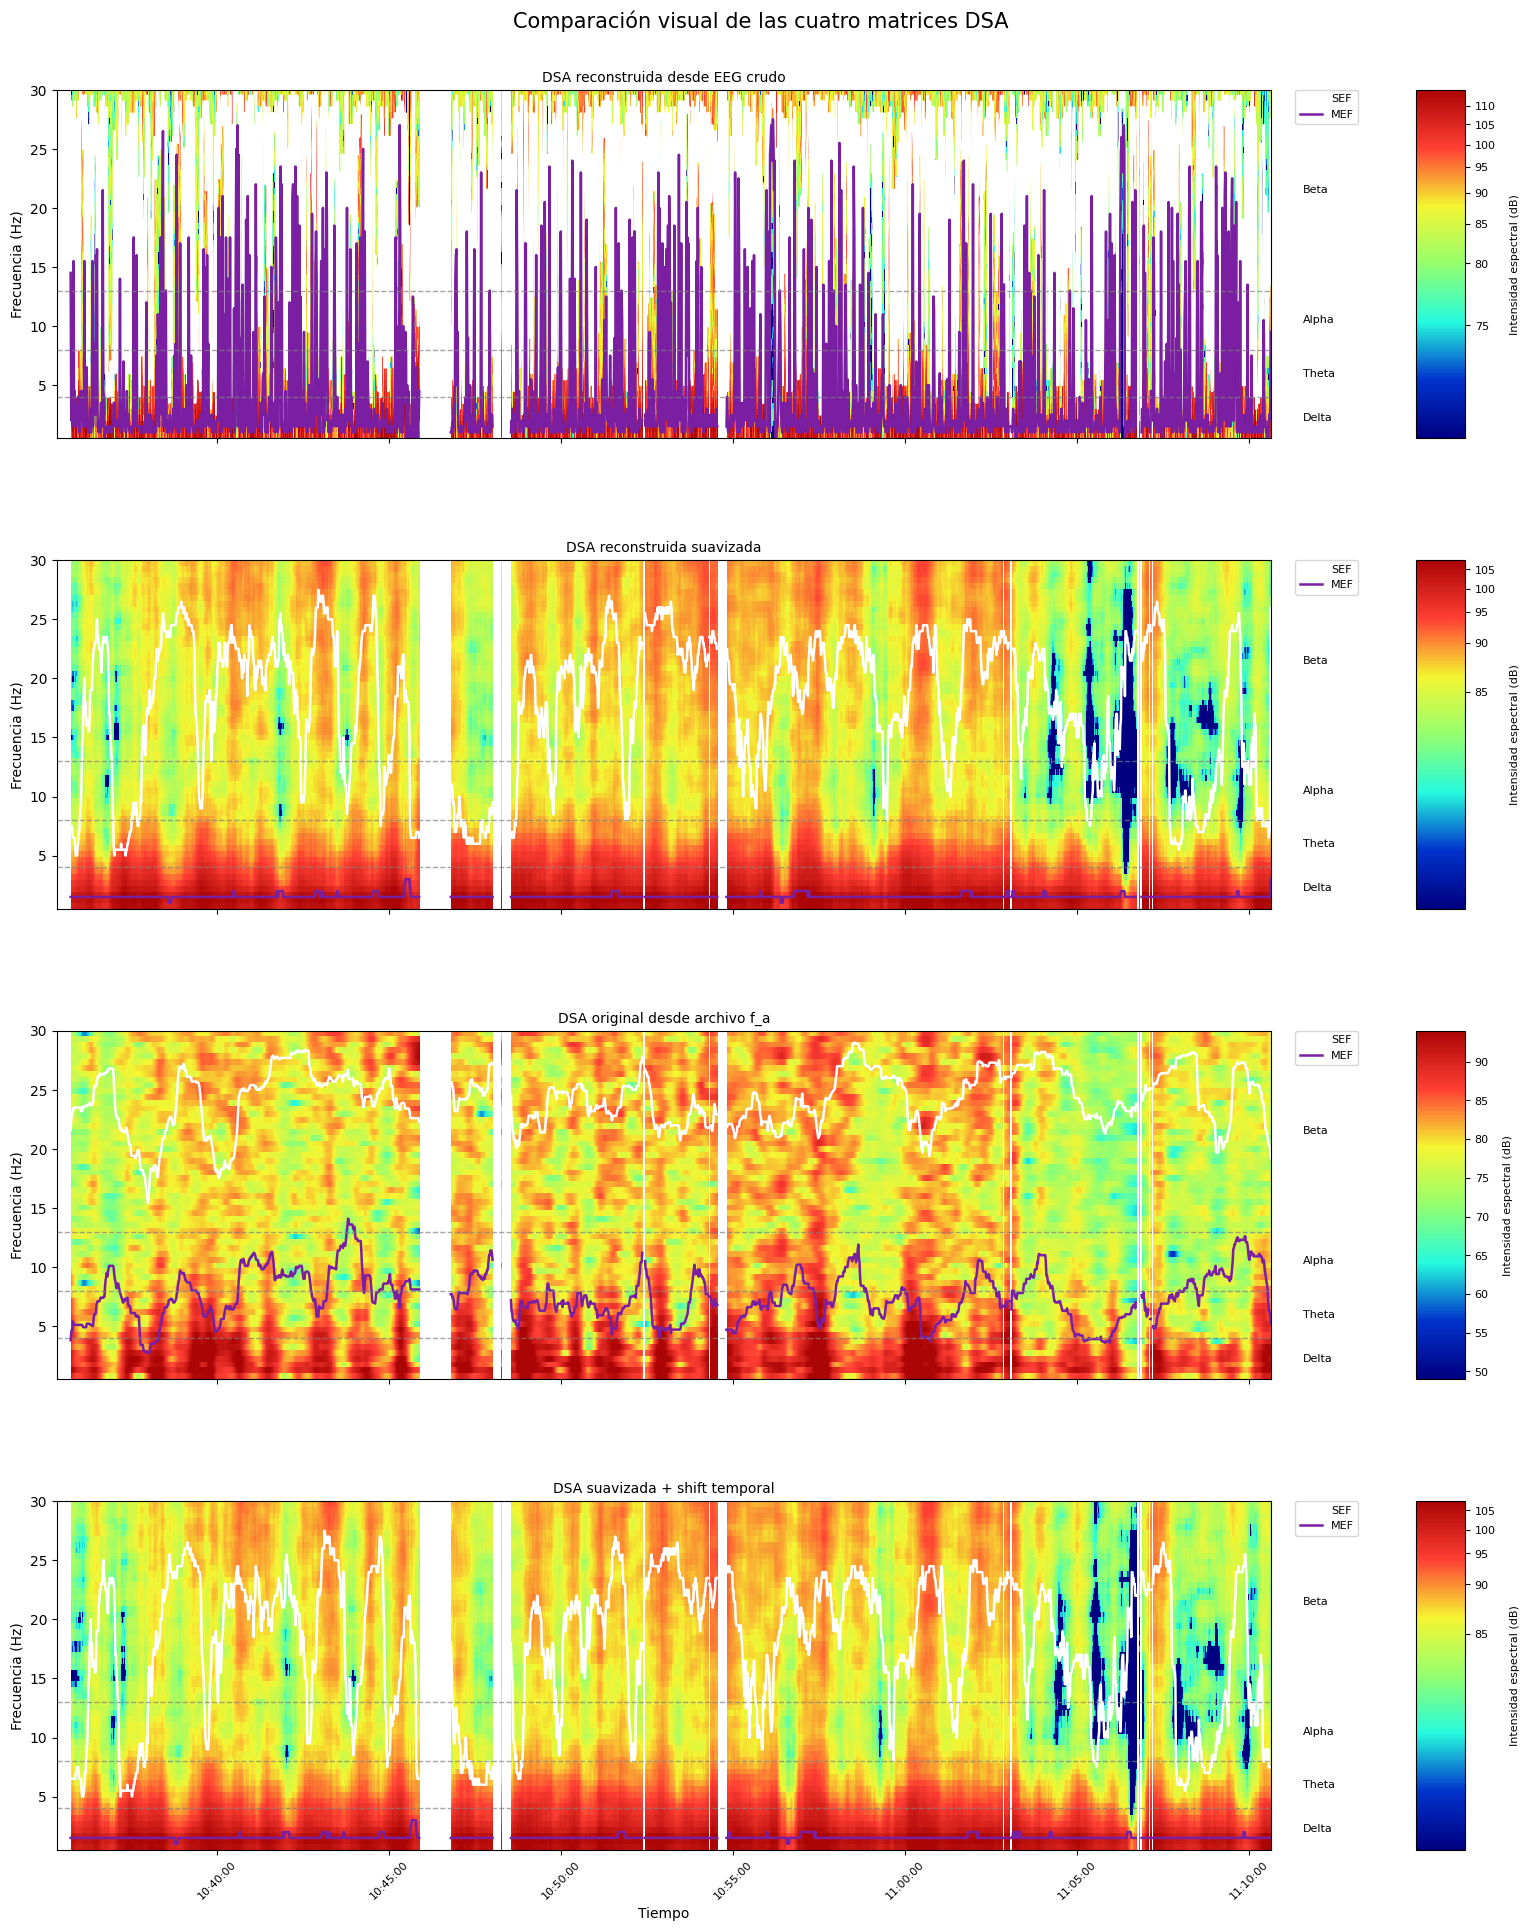

In [133]:
paneles = [
    
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_eeg,
        "norm": norm_eeg,
        "cmap": cmap_eeg,
        "df_merge": df_merge_eeg,
        "titulo": "DSA reconstruida desde EEG crudo",
        "mask_total": mask_comun,
        "mostrar_sef": True,
        "mostrar_mef": True
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt,
        "norm": norm_opt,
        "cmap": cmap_opt,
        "df_merge": df_merge_suav,
        "titulo": "DSA reconstruida suavizada",
        "mask_total": mask_comun,
        "mostrar_sef": True,
        "mostrar_mef": True
    },
    {
        "tiempo": tiempo_fa_unilat,
        "frecuencias": dsa_fa_plot.columns.astype(float),
        "matriz": matriz_fa,
        "norm": norm_fa,
        "cmap": cmap_fa,
        "df_merge": df_merge_hor,
        "titulo": "DSA original desde archivo f_a",
        "mask_total": mask_comun,
        "mostrar_sef": True,
        "mostrar_mef": True
    },
    {
        "tiempo": tiempo_eeg,
        "frecuencias": frecuencias_c1,
        "matriz": matriz_opt_desfase_full,
        "norm": norm_opt_desfase_full,
        "cmap": cmap_opt_desfase_full,
        "df_merge": df_merge_suav_shift_full,
        "titulo": "DSA suavizada + shift temporal",
        "mask_total": mask_comun,
        "mostrar_sef": True,
        "mostrar_mef": True
    }
]


fig_grid, axes_grid = fun_dsa.plot_cuadricula_4_dsa(
    paneles,
    titulo_general="Comparación visual de las cuatro matrices DSA"
)

# La que mejora un poco los resultados

In [22]:
import numpy as np
import pandas as pd
from scipy.signal import spectrogram

def crear_matriz_dsa_optimizada(
    df_eeg,
    canal,
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
):
    """
    Crea una matriz tiempo-frecuencia para DSA desde EEG crudo usando spectrogram (100x más rápido).
    """
    # 1. Extraer la señal como array de numpy
    x = df_eeg[canal].to_numpy(dtype=float)

    # 2. Calcular los parámetros de las ventanas en muestras
    nperseg = int(ventana_seg * fs)
    
    # El "noverlap" es cuántas muestras se solapan. 
    # Ej: Ventana de 2s (256), Paso de 0.5s (64) -> Solapamiento de 1.5s (192)
    noverlap = int((ventana_seg - paso_seg) * fs)
    
    # El tamaño de la FFT para lograr la resolución deseada (Zero-Padding)
    nfft = int(fs / paso_freq)

    # 3. Elegir el escalado
    scaling = "density" if modo in ["densidad", "db_densidad"] else "spectrum"

    # =====================================================================
    # 4. EL NÚCLEO OPTIMIZADO (Sustituye a todo el bucle for)
    # spectrogram calcula toda la matriz de golpe en lenguaje C
    # =====================================================================
    f, t_center, Sxx = spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend="constant",
        scaling=scaling
    )

    # Spectrogram devuelve la matriz Sxx como (Frecuencias, Tiempos).
    # Como queremos que las filas sean los tiempos (para el DataFrame), la transponemos (.T)
    Sxx = Sxx.T

    # 5. Filtrar solo las frecuencias deseadas (entre fmin y fmax)
    mascara_freq = (f >= fmin) & (f <= fmax)
    f_sel = f[mascara_freq]
    
    # Seleccionamos todas las filas (tiempos) pero solo las columnas (frecuencias) que nos interesan
    valores_sel = Sxx[:, mascara_freq]

    # 6. Aplicar la conversión matemática a toda la matriz de golpe
    if modo in ["potencia", "densidad"]:
        valores_finales = valores_sel
    elif modo == "amplitud":
        valores_finales = np.sqrt(valores_sel)
    elif modo in ["db", "db_densidad"]:
        # Se suma 1e-12 para evitar el logaritmo de cero
        valores_finales = 10 * np.log10(valores_sel + 1e-12)
    else:
        raise ValueError("modo debe ser 'db', 'db_densidad', 'potencia', 'densidad' o 'amplitud'")

    # 7. Ajustar el vector de tiempos según la referencia elegida
    # spectrogram devuelve 't_center' como el centro exacto de la ventana.
    if tiempo_referencia == "inicio":
        tiempos = t_center - (ventana_seg / 2)
    elif tiempo_referencia == "centro":
        tiempos = t_center
    elif tiempo_referencia == "final":
        tiempos = t_center + (ventana_seg / 2)
    else:
        raise ValueError("tiempo_referencia debe ser 'inicio', 'centro' o 'final'")

    # 8. Construir el DataFrame final
    df_dsa = pd.DataFrame(
        valores_finales,
        columns=[f"{freq:.1f}" for freq in f_sel]
    )
    df_dsa.insert(0, "tiempo_s", tiempos)

    return df_dsa, f_sel

In [23]:
# --- ADAPTACIÓN DE LAS LLAMADAS ---

df_dsa_canal1_prueba, frecuencias_c1_prueba = crear_matriz_dsa_optimizada(
    df_eeg,
    "canal_1_uV",
    fs=128,
    ventana_seg=1, # Ojo: En tus comentarios hablas de ventana de 2s, ¡asegúrate de poner el número que quieras usar!
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2_prueba, _ = crear_matriz_dsa_optimizada(
    df_eeg,
    "canal_2_uV",
    fs=128,
    ventana_seg=1,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq_prueba = [c for c in df_dsa_canal1_prueba.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media_prueba = df_dsa_canal1_prueba.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media_prueba = (
    df_dsa_canal1_prueba[cols_freq_prueba].to_numpy(dtype=float) +
    df_dsa_canal2_prueba[cols_freq_prueba].to_numpy(dtype=float)
) / 2

# array de los nombres de las columnas pasados a float
frecuencias_float_prueba = np.array([float(c) for c in cols_freq_prueba])

# calcular sef y mef solo para la dsa reconstruida del eeg 
# (basado en la potencia en uV)
# 1. Calculamos SEF y MEF (que tendrán 2119 o 2118 filas dependiendo de la ventana)
sef_eeg_prueba, mef_eeg_prueba = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media_prueba,
    frecuencias=frecuencias_float_prueba,
    percentil_sef=0.95,
    percentil_mef=0.50
)

# 2. Averiguamos la longitud objetivo (las filas del DataFrame de tu archivo .spa o .f_a)
# Suponiendo que tienes cargado el dF original del spa/f_a en una variable (ej: df_spa)
longitud_objetivo_prueba = len(df_spa_unilat) 
longitud_actual_prueba = len(sef_eeg_prueba)
filas_faltantes_prueba = longitud_objetivo_prueba - longitud_actual_prueba

# 3. Rellenamos dinámicamente con NaNs
if filas_faltantes_prueba > 0:
    # Creamos un array con tantos NaNs como falten (normalmente 1)
    relleno_nan_prueba = np.full(filas_faltantes_prueba, np.nan)
    
    # Los añadimos al principio
    sef_pad_prueba = np.r_[relleno_nan_prueba, sef_eeg_prueba]
    mef_pad_prueba = np.r_[relleno_nan_prueba, mef_eeg_prueba]
else:
    # Si la ventana es de 1s, filas_faltantes es 0, se queda igual
    sef_pad_prueba = sef_eeg_prueba
    mef_pad_prueba = mef_eeg_prueba

# 4. Creamos las Series finales para plotear
sef_eeg_plot_prueba = pd.Series(sef_pad_prueba, name="SEF08")
mef_eeg_plot_prueba = pd.Series(mef_pad_prueba, name="MEDFRQ08")

# --- CONVERSIÓN A DECIBELIOS (Usando la ref documentada del BIS) ---
ref_potencia = 0.0001
df_dsa_media_prueba[cols_freq_prueba] = 10 * np.log10(
    (pot_media_prueba + 1e-12) / (ref_potencia**2)
)

In [31]:
# El parámetro 'span' representa los segundos de inercia del filtro.
# El manual del BIS habla de ventanas SpSmooth de 15 o 30 segundos.
df_dsa_suavizada = df_dsa_media_prueba.copy()

# Aplica el filtro exponencial a lo largo del eje temporal (por columnas de frecuencia)
for col in cols_freq_prueba:
    df_dsa_suavizada[col] = df_dsa_media_prueba[col].ewm(span=15, adjust=False).mean()
    
    

df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg_prueba, dsa_eeg_prueba = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_suavizada,
    frecuencias=frecuencias_c1_prueba,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

df_merge_plot_prueba = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_prueba,
    df_spa=df_spa_unilat
)

df_merge_plot_prueba["SEF08"] = sef_eeg_plot_prueba.values
df_merge_plot_prueba["MEDFRQ08"] = mef_eeg_plot_prueba.values

_, mask_total_prueba = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_prueba,
    dsa=dsa_eeg_prueba,
    df_merge=df_merge_plot_prueba,
    umbral_sqi=15,
    umbral_ceros=0.9
)

mask_comun_prueba = mask_total_prueba.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color


In [32]:
# DSA reconstruida directa con máscara común

""" 
Copia de la dsa proveniente del eeg para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_eeg_directa_plot_prueba = dsa_eeg_prueba.copy()
dsa_eeg_directa_plot_prueba.loc[mask_comun_prueba.values, :] = np.nan

# Preparar escala de color
matriz_prueba, vmin_prueba, vmax_prueba, norm_prueba, cmap_prueba = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_directa_plot_prueba,
    gamma=0.3
)

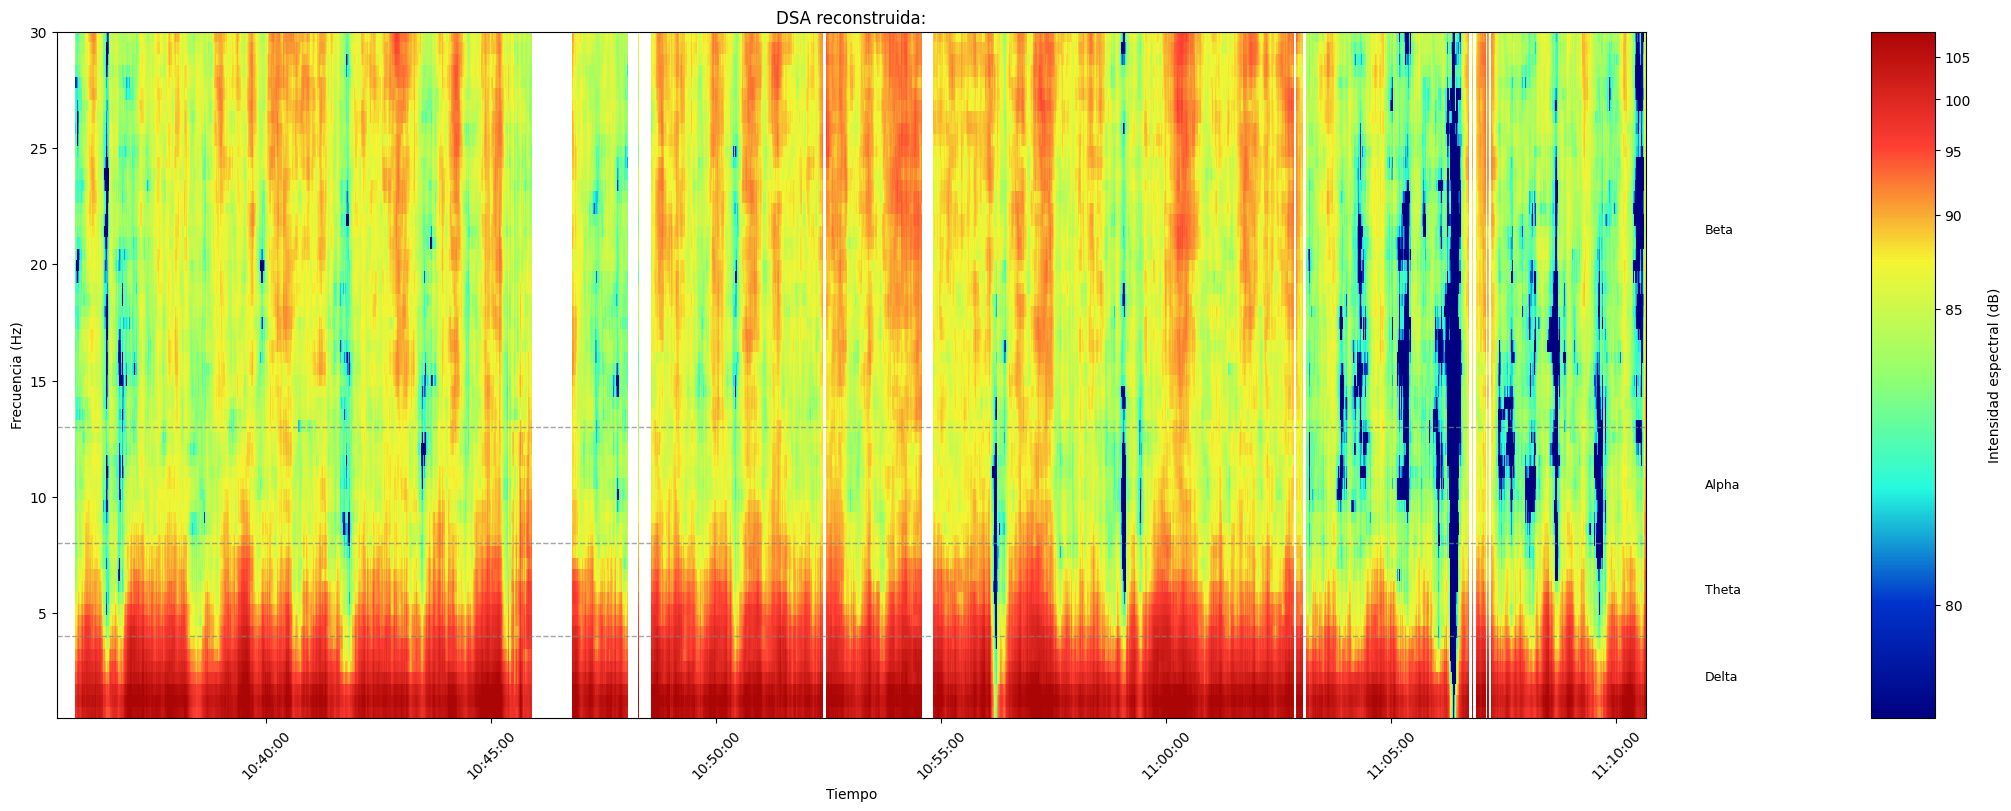

In [33]:
fig_prueba, ax_prueba, ax_band_prueba, cax_prueba = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg_prueba,
    frecuencias=frecuencias_c1_prueba,
    matriz=matriz_prueba,
    norm=norm_prueba,
    cmap=cmap_prueba,
    df_merge=df_merge_plot_prueba,
    titulo=f"DSA reconstruida:",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun_prueba,
    mostrar_sef=False,
    mostrar_mef=False
)

In [34]:
cols_freq_prueba = [c for c in dsa_eeg_directa_plot_prueba.columns]


print(np.nanmin(dsa_eeg_directa_plot_prueba[cols_freq_prueba].values))
print(np.nanmax(dsa_eeg_directa_plot_prueba[cols_freq_prueba].values))

print(np.nanpercentile(dsa_eeg_directa_plot_prueba[cols_freq_prueba].values, 2))
print(np.nanpercentile(dsa_eeg_directa_plot_prueba[cols_freq_prueba].values, 99.5))

68.35683329042328
112.6428710920131
79.93032185446755
108.31560256343815


In [35]:
# DSA original f_a con máscara común

""" 
Copia de la dsa proveniente del f_a para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun_prueba.values, :] = np.nan

dsa_eeg_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_directa_plot_prueba,
    dsa_fa_plot
)

In [37]:
ventanas_sp_smooth = [1, 5, 10, 30, 60]

df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comparacion,
    dsa_fa_comparacion,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=range(0, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
188,30,5,0.755885,0.739201,0.529532,0.697860
136,10,14,0.755767,0.721753,0.532523,0.697759
189,30,6,0.755701,0.738598,0.530232,0.698169
135,10,13,0.755444,0.721676,0.532482,0.698469
187,30,4,0.755342,0.738690,0.529740,0.698607
137,10,15,0.755040,0.720331,0.533889,0.698536
190,30,7,0.754739,0.736857,0.531918,0.699585


In [38]:
suavizado_final = 30

dsa_eeg_suav_prueba = dsa_eeg_prueba.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

# máscara común al final
dsa_eeg_suav_plot_prueba = dsa_eeg_suav_prueba.copy()
dsa_eeg_suav_plot_prueba.loc[mask_comun_prueba.values, :] = np.nan

matriz_opt_prueba, vmin_opt_prueba, vmax_opt_prueba, norm_opt_prueba, cmap_opt_prueba = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_plot_prueba,
    gamma=0.25
)

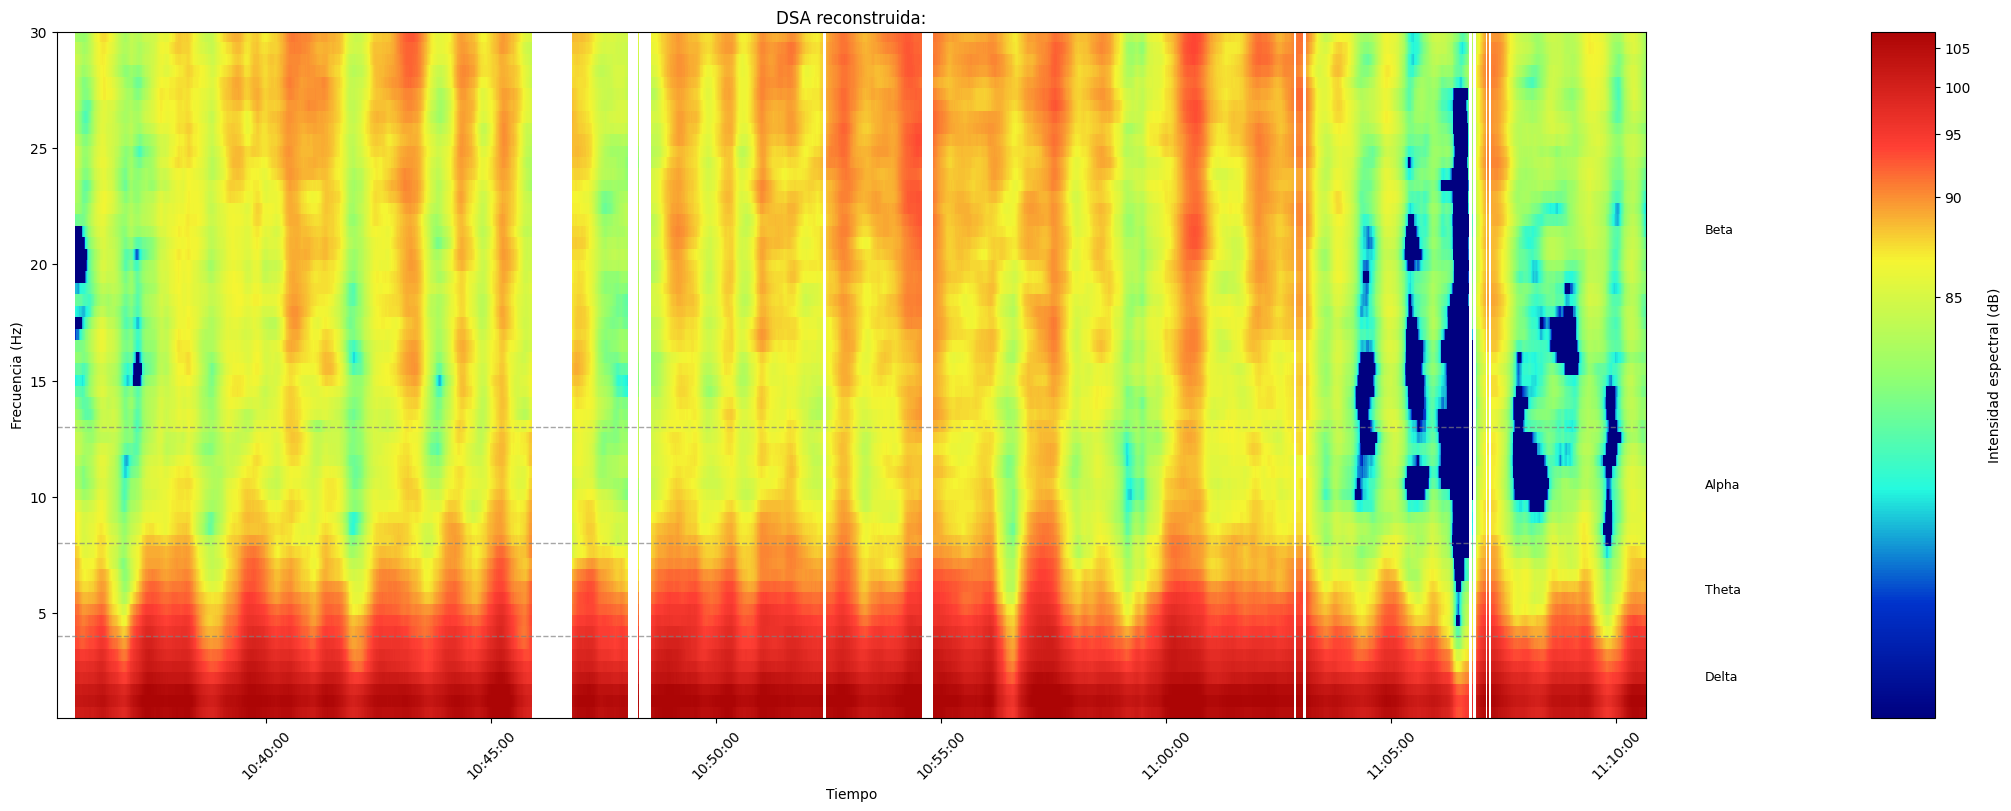

In [39]:
fig_opt_prueba, ax_opt_prueba, ax_opt_band_prueba, cax_prueba = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg_prueba,
    frecuencias=frecuencias_c1_prueba,
    matriz=matriz_opt_prueba,
    norm=norm_opt_prueba,
    cmap=cmap_opt_prueba,
    df_merge=df_merge_plot_prueba,
    titulo=f"DSA reconstruida:",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun_prueba,
    mostrar_sef=False,
    mostrar_mef=False
)

In [40]:
shift_final = 5

# matriz vacía del mismo tamaño que la DSA suavizada original
dsa_eeg_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_suav_prueba.index,
    columns=dsa_eeg_suav_prueba.columns
)

# Desplazar la DSA suavizada hacia delante:
# las filas originales 0:-shift pasan a ocupar las filas shift:
dsa_eeg_suav_shift_full.iloc[shift_final:, :] = dsa_eeg_suav_prueba.iloc[:-shift_final, :].to_numpy()

# Aplicar la máscara común sobre la línea temporal original completa
dsa_eeg_suav_shift_full.loc[mask_comun_prueba.values, :] = np.nan

# Preparar escala de color
matriz_opt_desfase_full, vmin_opt_desfase_full, vmax_opt_desfase_full, norm_opt_desfase_full, cmap_opt_desfase_full = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_full,
    gamma=0.25
)

print("Tiempo:", len(tiempo_fa_unilat))
print("f_a:", matriz_hor.shape)
print("shift full:", matriz_opt_desfase_full.shape)

Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


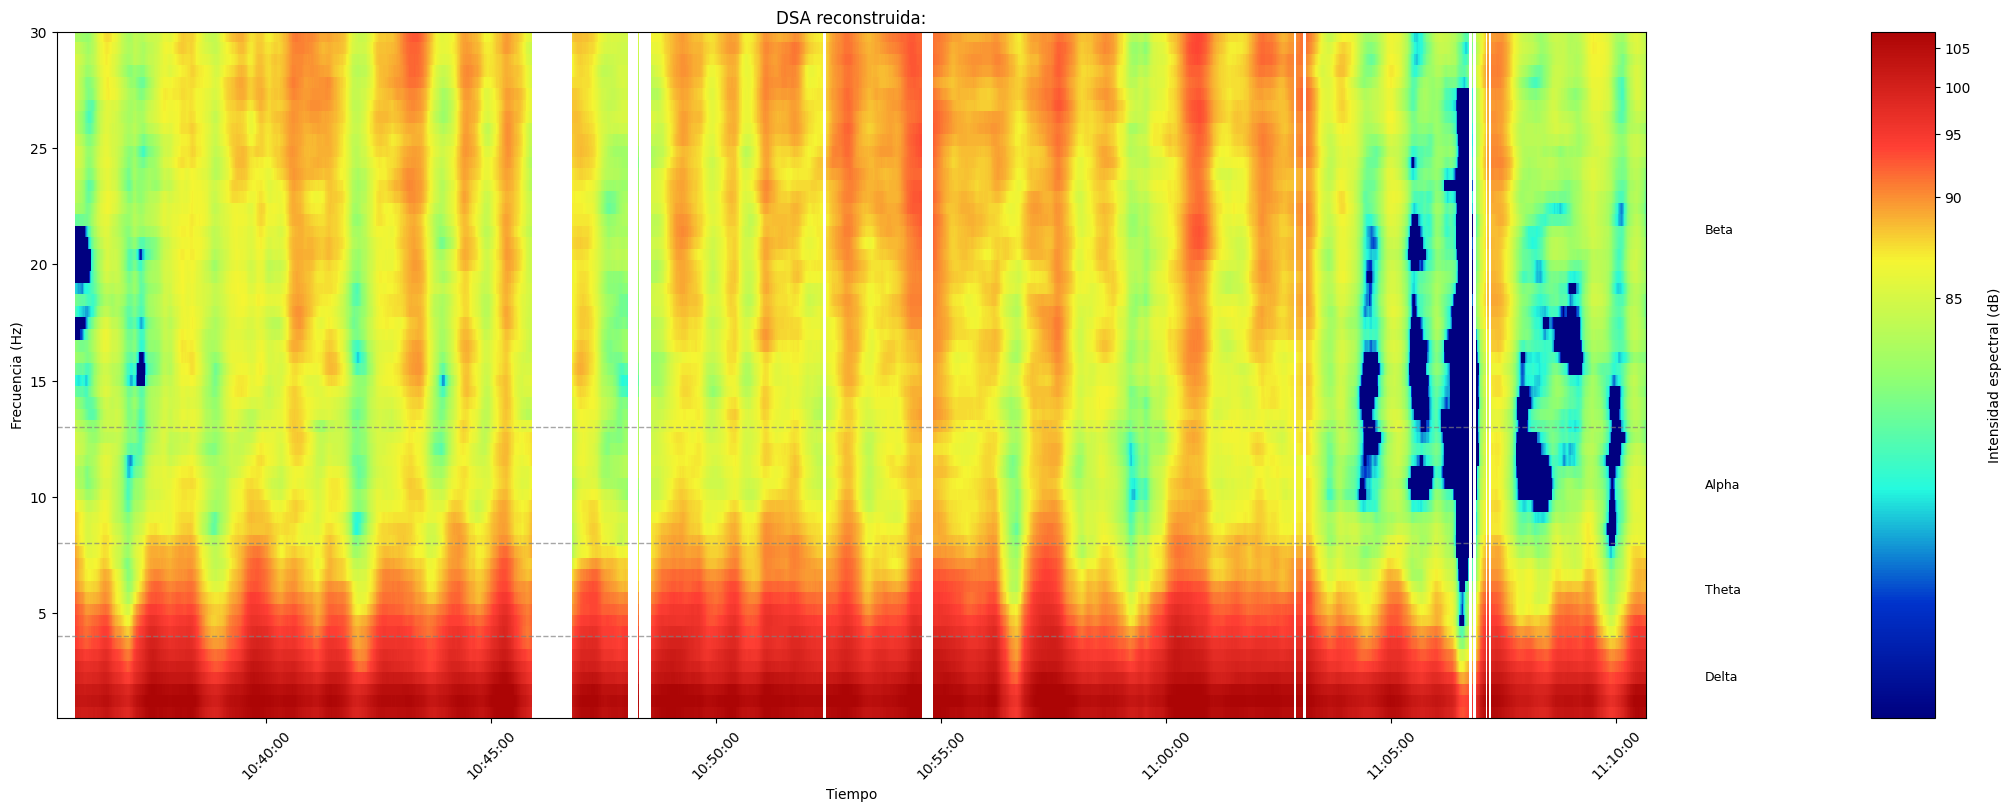

In [41]:
fig_opt_prueba, ax_opt_prueba, ax_opt_band_prueba, cax_prueba = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg_prueba,
    frecuencias=frecuencias_c1_prueba,
    matriz=matriz_opt_desfase_full,
    norm=norm_opt_desfase_full,
    cmap=cmap_opt_desfase_full,
    df_merge=df_merge_plot_prueba,
    titulo=f"DSA reconstruida:",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun_prueba,
    mostrar_sef=False,
    mostrar_mef=False
)

In [29]:
dsa_suav_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_suav_plot_prueba,
    dsa_fa_plot
)

dsa_shift_comparacion, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_suav_shift_full,
    dsa_fa_plot
)

# La que más se acerca visualmente al bis

In [49]:
pip install PyWavelets


   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------------------ --------------- 2.6/4.2 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 21.0 MB/s  0:00:00


In [77]:
import numpy as np
import pandas as pd
import pywt  # Importamos el estándar de wavelets

def crear_matriz_dsa_wavelet(
    df_eeg,
    canal,
    fs=128,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5
):
    """
    Crea una matriz DSA usando Transformada Wavelet Continua (CWT) con PyWavelets.
    """
    # 1. Extraer la señal cruda
    x = df_eeg[canal].to_numpy(dtype=float)
    
    # 2. Definir frecuencias deseadas
    frecuencias = np.arange(fmin, fmax + paso_freq, paso_freq)
    
    # 3. Calcular las escalas exactas para PyWavelets
    # Nombre de la wavelet de Morlet continua en pywt
    wavelet_name = 'morl' 
    
    # Frecuencia central matemática de la Morlet
    fc = pywt.central_frequency(wavelet_name) 
    
    # Ecuación de conversión automática de Frecuencia a Escala
    escalas = fc / (frecuencias * (1 / fs))
    
    # =====================================================================
    # 4. EL NÚCLEO WAVELET (PyWavelets es mucho más rápido que SciPy)
    # =====================================================================
    coeficientes, _ = pywt.cwt(x, escalas, wavelet_name, sampling_period=1/fs)
    
    # 5. Convertir a Potencia Absoluta
    potencia_cwt = np.abs(coeficientes)**2
    
    # 6. Compresión Temporal (Agrupar 128 muestras en 1 segundo)
    num_segundos = len(x) // fs
    potencia_segundos = np.zeros((len(frecuencias), num_segundos))
    
    for i in range(num_segundos):
        inicio = i * fs
        fin = inicio + fs
        # Promediamos la energía de esas 128 muestras para resumir ese segundo
        potencia_segundos[:, i] = np.mean(potencia_cwt[:, inicio:fin], axis=1)
        
    # 7. Transponer y construir el DataFrame final
    matriz_final = potencia_segundos.T
    tiempos = np.arange(num_segundos) + 0.5 
    
    df_dsa = pd.DataFrame(
        matriz_final,
        columns=[f"{freq:.1f}" for freq in frecuencias]
    )
    df_dsa.insert(0, "tiempo_s", tiempos)
    
    return df_dsa, frecuencias

In [78]:
# --- ADAPTACIÓN DE LAS LLAMADAS ---

df_dsa_canal1_wt, frecuencias_c1_wt = crear_matriz_dsa_wavelet(
    df_eeg,
    canal="canal_1_uV",
    fs=128,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5
)

df_dsa_canal2_wt, _ = crear_matriz_dsa_wavelet(
    df_eeg,
    canal="canal_2_uV",
    fs=128,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5
)

# columnas del dF generado después de la conversión por FFT -> las frecuencias
cols_freq_wt = [c for c in df_dsa_canal1_wt.columns if c != "tiempo_s"]

# copia del dF del canal 1 para tener esa estructura
df_dsa_media_wt = df_dsa_canal1_wt.copy()

# media (en float) de las potencias (en uV) de los 2 canales
# en función de las frecuencias 
pot_media_wt = (
    df_dsa_canal1_wt[cols_freq_wt].to_numpy(dtype=float) +
    df_dsa_canal2_wt[cols_freq_wt].to_numpy(dtype=float)
) / 2

# array de los nombres de las columnas pasados a float
frecuencias_float_wt = np.array([float(c) for c in cols_freq_wt])

# calcular sef y mef solo para la dsa reconstruida del eeg 
# (basado en la potencia en uV)
# 1. Calculamos SEF y MEF (que tendrán 2119 o 2118 filas dependiendo de la ventana)
sef_eeg_wt, mef_eeg_wt = fun_dsa.calcular_sef_mef_desde_potencia(
    potencia=pot_media_wt,
    frecuencias=frecuencias_float_wt,
    percentil_sef=0.95,
    percentil_mef=0.50
)

# 2. Averiguamos la longitud objetivo (las filas del DataFrame de tu archivo .spa o .f_a)
# Suponiendo que tienes cargado el dF original del spa/f_a en una variable (ej: df_spa)
longitud_objetivo_wt = len(df_spa_unilat) 
longitud_actual_wt = len(sef_eeg_wt)
filas_faltantes_wt = longitud_objetivo_wt - longitud_actual_wt

# 3. Rellenamos dinámicamente con NaNs
if filas_faltantes_wt > 0:
    # Creamos un array con tantos NaNs como falten (normalmente 1)
    relleno_nan_wt = np.full(filas_faltantes_wt, np.nan)
    
    # Los añadimos al principio
    sef_pad_wt = np.r_[relleno_nan_wt, sef_eeg_wt]
    mef_pad_wt = np.r_[relleno_nan_wt, mef_eeg_wt]
else:
    # Si la ventana es de 1s, filas_faltantes es 0, se queda igual
    sef_pad_wt = sef_eeg_wt
    mef_pad_wt = mef_eeg_wt

# 4. Creamos las Series finales para plotear
sef_eeg_plot_wt = pd.Series(sef_pad_wt, name="SEF08")
mef_eeg_plot_wt = pd.Series(mef_pad_wt, name="MEDFRQ08")

# --- CONVERSIÓN A DECIBELIOS (Usando la ref documentada del BIS) ---
ref_potencia = 0.0001
df_dsa_media_wt[cols_freq_wt] = 10 * np.log10(
    (pot_media_wt + 1e-12) / (ref_potencia**2)
)

In [79]:
# El parámetro 'span' representa los segundos de inercia del filtro.
# El manual del BIS habla de ventanas SpSmooth de 15 o 30 segundos.
df_dsa_suavizada_wt = df_dsa_media_wt.copy()

# Aplica el filtro exponencial a lo largo del eje temporal (por columnas de frecuencia)
for col in cols_freq_wt:
    df_dsa_suavizada_wt[col] = df_dsa_media_wt[col].ewm(span=15, adjust=False).mean()
    
    

df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg_wt, dsa_eeg_wt = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_suavizada_wt,
    frecuencias=frecuencias_c1_wt,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

df_merge_plot_wt = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg_wt,
    df_spa=df_spa_unilat
)

df_merge_plot_wt["SEF08"] = sef_eeg_plot_wt.values
df_merge_plot_wt["MEDFRQ08"] = mef_eeg_plot_wt.values

_, mask_total_wt = fun_dsa.preparar_dsa_con_mask(
    tiempo=tiempo_eeg_wt,
    dsa=dsa_eeg_wt,
    df_merge=df_merge_plot_wt,
    umbral_sqi=15,
    umbral_ceros=0.9
)

mask_comun_wt = mask_total_wt.copy()

# en las reconstrucciones se utilizan como valores mínimos y máximos 
# los percentiles más ajustados para replicar el color


In [80]:
# DSA reconstruida directa con máscara común

""" 
Copia de la dsa proveniente del eeg para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_eeg_directa_plot_wt = dsa_eeg_wt.copy()
dsa_eeg_directa_plot_wt.loc[mask_comun_wt.values, :] = np.nan
 
# Preparar escala de color
matriz_wt, vmin_wt, vmax_wt, norm_wt, cmap_wt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_directa_plot_wt,
    gamma=0.3
)

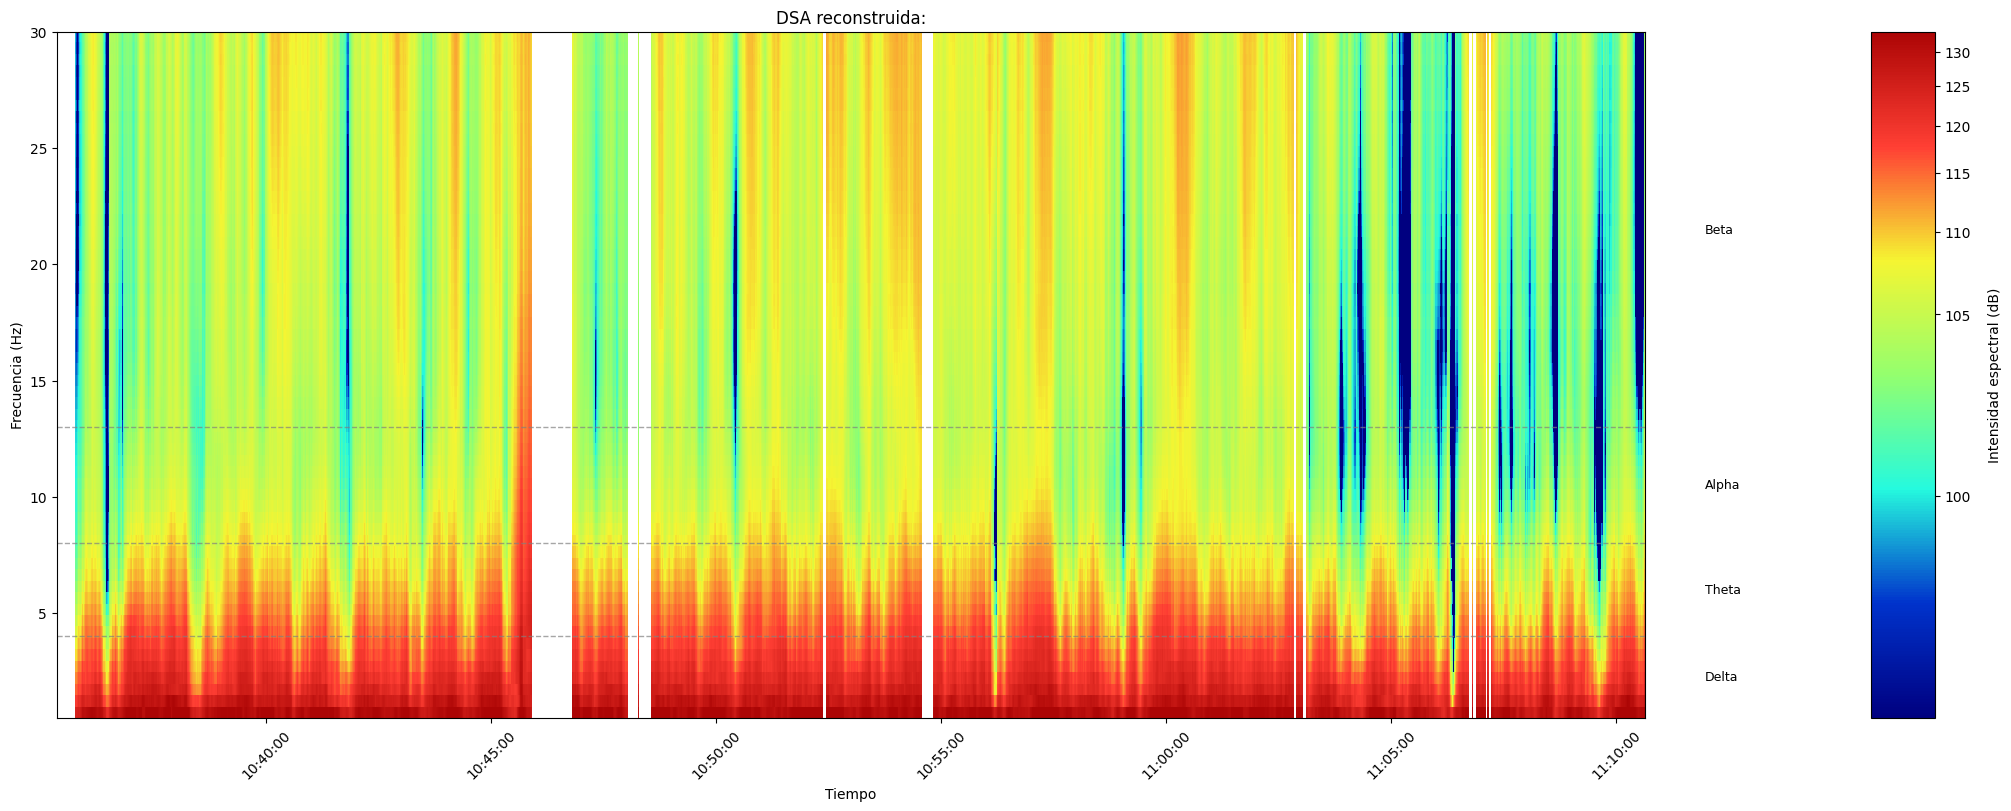

In [81]:
fig_wt, ax_wt, ax_band_wt, cax_wt = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg_wt,
    frecuencias=frecuencias_c1_wt,
    matriz=matriz_wt,
    norm=norm_wt,
    cmap=cmap_wt,
    df_merge=df_merge_plot_wt,
    titulo=f"DSA reconstruida:",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun_wt,
    mostrar_sef=False,
    mostrar_mef=False
)

In [82]:
cols_freq_wt = [c for c in dsa_eeg_directa_plot_wt.columns]


print(np.nanmin(dsa_eeg_directa_plot_wt[cols_freq_wt].values))
print(np.nanmax(dsa_eeg_directa_plot_wt[cols_freq_wt].values))

print(np.nanpercentile(dsa_eeg_directa_plot_wt[cols_freq_wt].values, 2))
print(np.nanpercentile(dsa_eeg_directa_plot_wt[cols_freq_wt].values, 99.5))

91.57923899289197
139.08614101735225
99.20691761049622
133.20848430051672


In [103]:
# DSA original f_a con máscara común

""" 
Copia de la dsa proveniente del f_a para incluirla en el plot
 - .loc[mask_comun.values, :]: selecciona todas las filas donde mask_comun vale True, y todas las columnas de frecuencia.
 - np.nan: como el colormap pinta los NaN en blanco, esas filas aparecerán como bandas blancas.
"""

dsa_fa_plot = dsa_unilat.copy()
dsa_fa_plot.loc[mask_comun_wt.values, :] = np.nan

dsa_eeg_comparacion_wt, dsa_fa_comparacion = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_directa_plot_wt,
    dsa_fa_plot
)

In [104]:
ventanas_sp_smooth = [1, 5, 10, 30, 60]

df_suav_shift_wt = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comparacion_wt,
    dsa_fa_comparacion,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=range(0, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(7)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
188,30,5,0.755885,0.739201,0.529532,0.697860
136,10,14,0.755767,0.721753,0.532523,0.697759
189,30,6,0.755701,0.738598,0.530232,0.698169
135,10,13,0.755444,0.721676,0.532482,0.698469
187,30,4,0.755342,0.738690,0.529740,0.698607
137,10,15,0.755040,0.720331,0.533889,0.698536
190,30,7,0.754739,0.736857,0.531918,0.699585


In [105]:
suavizado_final = 30

dsa_eeg_suav_wt = dsa_eeg_wt.copy().rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()

In [106]:
shift_final = 5

# matriz vacía del mismo tamaño que la DSA suavizada original
dsa_eeg_suav_shift_full_wt = pd.DataFrame(
    np.nan,
    index=dsa_eeg_suav_wt.index,
    columns=dsa_eeg_suav_wt.columns
)

# Desplazar la DSA suavizada hacia delante:
# las filas originales 0:-shift pasan a ocupar las filas shift:
dsa_eeg_suav_shift_full_wt.iloc[shift_final:, :] = dsa_eeg_suav_wt.iloc[:-shift_final, :].to_numpy()

# Aplicar la máscara común sobre la línea temporal original completa
dsa_eeg_suav_shift_full_wt.loc[mask_comun_wt.values, :] = np.nan

# Preparar escala de color
matriz_opt_desfase_full_wt, vmin_opt_desfase_full_wt, vmax_opt_desfase_full_wt, norm_opt_desfase_full_wt, cmap_opt_desfase_full_wt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_suav_shift_full_wt,
    gamma=0.25
)

print("Tiempo:", len(tiempo_fa_unilat))
print("f_a:", matriz_hor.shape)
print("shift full:", matriz_opt_desfase_full_wt.shape)

Tiempo: 2119
f_a: (2119, 60)
shift full: (2119, 60)


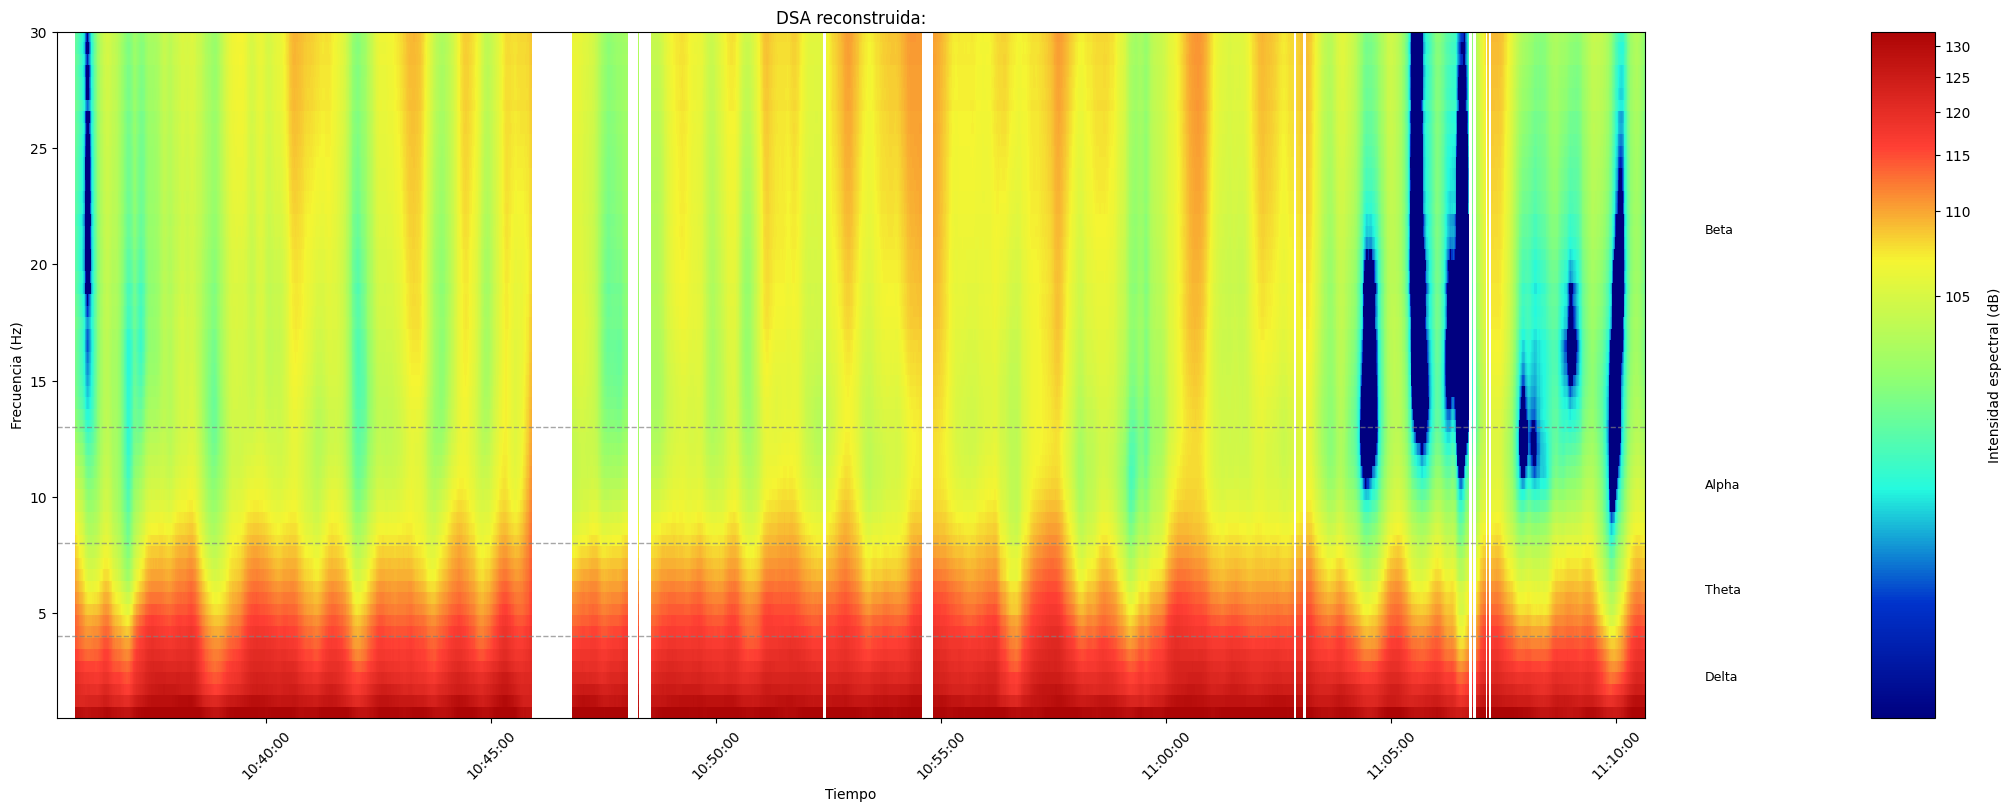

In [107]:
fig_opt_prueba, ax_opt_prueba, ax_opt_band_prueba, cax_prueba = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg_wt,
    frecuencias=frecuencias_c1_wt,
    matriz=matriz_opt_desfase_full_wt,
    norm=norm_opt_desfase_full_wt,
    cmap=cmap_opt_desfase_full_wt,
    df_merge=df_merge_plot_wt,
    titulo=f"DSA reconstruida:",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_comun_wt,
    mostrar_sef=False,
    mostrar_mef=False
)